<a href="https://colab.research.google.com/github/matildacr/ACTCLASE/blob/main/Construccion_modelo_wine_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Construcción del modelo de clasificación de vinos



## Carga y preparación inicial

### Paso 1. Importar las librerías

Se importan las librerías necesarias para manipulación de datos, visualización, división de datos, escalamiento, construcción de un Pipeline, entrenamiento de un SVM, evaluación del modelo y almacenamiento del modelo.

In [19]:
import os
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### Paso 2. Cargar el dataset

Se carga el dataset Wine disponible en scikit-learn, se convierte en un DataFrame, se agrega la variable objetivo y se muestran los primeros registros.

In [20]:
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Modificar la variable objetivo

### Paso 3. Asignar nombres a las clases

Se crea la columna `tipo_vino` con el nombre correspondiente a cada clase: 0 = Cabernet, 1 = Merlot, 2 = Pinot Noir.

Estas etiquetas se utilizan únicamente con fines didácticos y no corresponden a variedades identificadas por el dataset original.

In [21]:
nombres = {0: "Cabernet", 1: "Merlot", 2: "Pinot Noir"}

df["tipo_vino"] = df["target"].map(nombres)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,tipo_vino
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Cabernet
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Cabernet
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Cabernet
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Cabernet
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Cabernet


## Exploración de los datos

### Paso 4. Realizar una exploración inicial

Se obtienen las dimensiones del dataset, la cantidad de variables, los tipos de datos, los valores nulos, las estadísticas descriptivas y la cantidad de registros por tipo de vino.

In [22]:
print("Dimensiones del dataset:", df.shape)
print("Cantidad de variables:", df.shape[1])

Dimensiones del dataset: (178, 15)
Cantidad de variables: 15


In [23]:
df.dtypes

,0
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64


In [24]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [25]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [26]:
df["tipo_vino"].value_counts()

,count
tipo_vino,
Merlot,71
Cabernet,59
Pinot Noir,48


**¿Existen valores faltantes?**
No, todas las columnas tienen 0 valores nulos.

**¿Las tres clases contienen la misma cantidad de registros?**
No. Merlot tiene 71, Cabernet 59 y Pinot Noir 48.

**¿Se observa alguna diferencia importante entre las escalas de las variables?**
Sí. Por ejemplo, `proline` tiene valores de cientos a más de mil, mientras que otras variables como `malic_acid` o `hue` tienen valores pequeños. Por eso es necesario escalar los datos.

## Selección de características

### Paso 5. Definir las variables del modelo

Se utilizan únicamente las características `alcohol`, `malic_acid`, `color_intensity` y `proline`.

- X: las cuatro características seleccionadas.
- y: el tipo de vino.

Se comprueban las dimensiones de ambas variables.

In [27]:
caracteristicas = ["alcohol", "malic_acid", "color_intensity", "proline"]

X = df[caracteristicas]
y = df["tipo_vino"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (178, 4)
Dimensiones de y: (178,)


## Separación de los datos

### Paso 6. Crear los conjuntos de entrenamiento y prueba

Se dividen los datos en 80 % para entrenamiento y 20 % para prueba, con `random_state = 42` y división estratificada utilizando la variable objetivo. Se muestran las dimensiones obtenidas.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (142, 4)
X_test: (36, 4)
y_train: (142,)
y_test: (36,)


**¿Por qué no se utiliza el 100 % de los datos para entrenar?**
Porque se necesitan datos que el modelo no haya visto para evaluar si realmente aprendió a clasificar vinos nuevos.

**¿Qué función cumple la estratificación?**
Mantiene la misma proporción de cada tipo de vino en el conjunto de entrenamiento y en el de prueba.

## Construcción y entrenamiento del Pipeline

### Paso 7. Crear el Pipeline

Se construye un Pipeline compuesto por:

1. StandardScaler
2. SVC con kernel linear

In [29]:
modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

modelo

Pipeline(steps=[('scaler', StandardScaler()), ('svm', SVC(kernel='linear'))])

### Paso 8. Entrenar el modelo

Se entrena el Pipeline utilizando únicamente los datos de entrenamiento. Al finalizar se muestran las clases aprendidas por el modelo.

In [30]:
modelo.fit(X_train, y_train)

print("Clases aprendidas:", modelo.classes_)

Clases aprendidas: ['Cabernet' 'Merlot' 'Pinot Noir']


**¿Por qué resulta conveniente incluir el escalamiento y el modelo dentro del mismo Pipeline?**
Porque el escalamiento se aprende solo con los datos de entrenamiento y se aplica automáticamente igual a cualquier dato nuevo. Así se evitan errores y el modelo se guarda completo en un solo archivo.

## Predicción y evaluación

### Paso 9. Realizar las predicciones

Se utiliza el conjunto de prueba para generar las predicciones y se crea un DataFrame que permite comparar el valor real con el predicho.

In [31]:
y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": y_pred
})

comparacion

,Real,Predicho
0,Cabernet,Cabernet
1,Pinot Noir,Merlot
2,Cabernet,Cabernet
3,Merlot,Pinot Noir
4,Merlot,Merlot
5,Cabernet,Cabernet
6,Cabernet,Cabernet
7,Merlot,Merlot
8,Merlot,Merlot
9,Pinot Noir,Pinot Noir


### Paso 10. Evaluar el modelo

Se calculan Accuracy, Precision, Recall y F1-score, y se analizan los resultados para cada tipo de vino.

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.9166666666666666

              precision    recall  f1-score   support

    Cabernet       1.00      1.00      1.00        12
      Merlot       0.87      0.93      0.90        14
  Pinot Noir       0.89      0.80      0.84        10

    accuracy                           0.92        36
   macro avg       0.92      0.91      0.91        36
weighted avg       0.92      0.92      0.92        36



**Análisis por tipo de vino**

- El modelo obtuvo un accuracy de aproximadamente 92 %.
- **Cabernet:** precision, recall y F1-score de 1.00. Todos los Cabernet fueron clasificados correctamente.
- **Merlot:** F1-score de 0.90. Casi todos fueron reconocidos, aunque el modelo confundió algunos Pinot Noir como Merlot.
- **Pinot Noir:** es la clase con menor desempeño, con recall de 0.80 y F1-score de 0.84.

## Matriz de confusión y nueva predicción

### Paso 11. Crear la matriz de confusión

Se genera y visualiza la matriz de confusión utilizando los nombres Cabernet, Merlot y Pinot Noir.

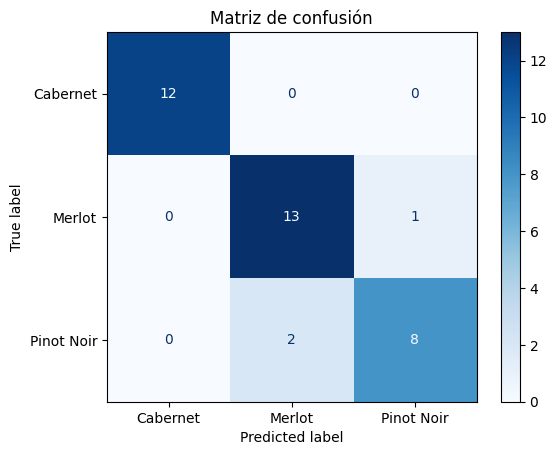

In [33]:
etiquetas = ["Cabernet", "Merlot", "Pinot Noir"]

matriz = confusion_matrix(y_test, y_pred, labels=etiquetas)

ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=etiquetas).plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

**Predicciones correctas:** 33 de 36 (los valores de la diagonal: 12 Cabernet, 13 Merlot y 8 Pinot Noir).

**Errores de clasificación:** 3. Un Merlot fue clasificado como Pinot Noir y dos Pinot Noir fueron clasificados como Merlot.

**Clases que presentan mayor confusión:** Merlot y Pinot Noir. Cabernet no tuvo ningún error.

### Paso 12. Probar un nuevo vino

Se crea un DataFrame con una nueva observación y se utiliza el modelo entrenado para determinar el tipo de vino predicho.

In [34]:
nuevo_vino = pd.DataFrame({
    "alcohol": [13.5],
    "malic_acid": [1.8],
    "color_intensity": [5.2],
    "proline": [1000]
})

prediccion = modelo.predict(nuevo_vino)

print("Tipo de vino predicho:", prediccion[0])

Tipo de vino predicho: Cabernet


## Guardar y recuperar el modelo

### Paso 13. Guardar el modelo

Se utiliza Joblib para almacenar el Pipeline entrenado. El nombre del archivo incluye la fecha y hora de creación. Se comprueba que el archivo haya sido generado correctamente.

In [35]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
archivo_modelo = f"modelo_wine_{timestamp}.pkl"

joblib.dump(modelo, archivo_modelo)

print("Archivo generado:", archivo_modelo)
print("¿Existe el archivo?:", os.path.exists(archivo_modelo))

Archivo generado: modelo_wine_20260925_000812.pkl
¿Existe el archivo?: True


### Paso 14. Recuperar el modelo

Se carga el archivo `modelo_wine.pkl`, se realiza una predicción con el modelo recuperado y se compara con la predicción realizada antes de guardar el modelo.

In [36]:
modelo_recuperado = joblib.load("modelo_wine.pkl")

prediccion_recuperada = modelo_recuperado.predict(nuevo_vino)

print("Predicción antes de guardar:", prediccion[0])
print("Predicción del modelo recuperado:", prediccion_recuperada[0])
print("¿Son iguales?:", prediccion[0] == prediccion_recuperada[0])

Predicción antes de guardar: Cabernet
Predicción del modelo recuperado: Cabernet
¿Son iguales?: True


/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. 

## Reflexión final

**Diferencia entre entrenar un modelo y utilizar un modelo previamente entrenado**

Entrenar un modelo es el proceso en el que el algoritmo aprende a partir de datos conocidos: se preparan los datos, se ajusta el escalador y el SVM encuentra cómo separar las clases. Esto requiere datos con etiquetas y tiempo de procesamiento.

Utilizar un modelo previamente entrenado es solo cargar el archivo donde se guardó lo aprendido y usarlo para predecir datos nuevos, sin volver a entrenar.

**Flujo:**

Datos → preparación → Pipeline → entrenamiento → evaluación → Joblib → modelo_wine.pkl

Se cargaron los datos del dataset Wine, se prepararon asignando nombres a las clases y seleccionando cuatro características, se construyó un Pipeline con escalamiento y SVM, se entrenó con el 80 % de los datos, se evaluó con el 20 % restante y finalmente se guardó con Joblib en el archivo `modelo_wine.pkl` para poder reutilizarlo.